In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('cleaned_data.csv')

df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   transmission  3898 non-null   str    
 1   mileage       3898 non-null   float64
 2   tax           3898 non-null   float64
 3   mpg           3898 non-null   float64
 4   fuel type     3898 non-null   str    
 5   engine size   3898 non-null   float64
 6   price_cad     3898 non-null   float64
 7   car_age       3898 non-null   float64
dtypes: float64(6), str(2)
memory usage: 243.8 KB


transmission    0
mileage         0
tax             0
mpg             0
fuel type       0
engine size     0
price_cad       0
car_age         0
dtype: int64

In [40]:
df.columns

Index(['transmission', 'mileage', 'tax', 'mpg', 'fuel type', 'engine size',
       'price_cad', 'car_age'],
      dtype='str')

In [42]:
df_raw = pd.read_csv('cleaned_data.csv')

print(df_raw['transmission'].unique())
print(df_raw['fuel type'].unique())

<StringArray>
['Automatic', 'Semi-Auto', 'Manual', 'Other']
Length: 4, dtype: str
<StringArray>
['Petrol', 'Diesel', 'Hybrid', 'Other']
Length: 4, dtype: str


In [44]:
# Count how many "Other" values exist in each column
print("Transmission 'Other' count:")
print(df['transmission'].value_counts())

print("\nFuel Type 'Other' count:")
print(df['fuel type'].value_counts())

Transmission 'Other' count:
transmission
Semi-Auto    2071
Automatic    1627
Manual        199
Other           1
Name: count, dtype: int64

Fuel Type 'Other' count:
fuel type
Diesel    2339
Petrol    1402
Hybrid     151
Other        6
Name: count, dtype: int64


In [47]:
# Drop rows where transmission or fuel type is "Other"
df = df[(df['transmission'] != 'Other') & (df['fuel type'] != 'Other')]

print("Transmission unique values")
print(df['transmission'].unique())

print("\nFuel Type unique values")
print(df['fuel type'].unique())

Transmission unique values
<StringArray>
['Automatic', 'Semi-Auto', 'Manual']
Length: 3, dtype: str

Fuel Type unique values
<StringArray>
['Petrol', 'Diesel', 'Hybrid']
Length: 3, dtype: str


In [ ]:
#Encoding transmission and fuel type for moedling
df = pd.get_dummies(df, columns=['transmission', 'fuel type'], drop_first=True)

In [ ]:
#Doing multiple linear regression model in order to see prediction

X = df.drop('price_cad', axis=1)
y = df['price_cad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

carPredict = LinearRegression()
carPredict.fit(X_train_scaled, y_train)

y_pred = carPredict.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Linear Regression R² score: {r2:.3f}")
print(f"Linear Regression Root Mean Square Error: {rmse:.2f} CAD")

Linear Regression R² score: 0.797
Linear Regression RMSE: 7469.89 CAD


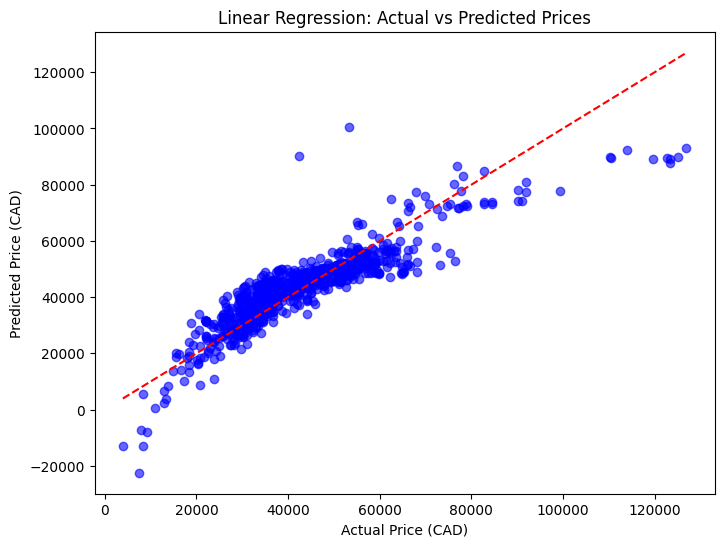

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.xlabel('Actual Price (CAD)')
plt.ylabel('Predicted Price (CAD)')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.show()

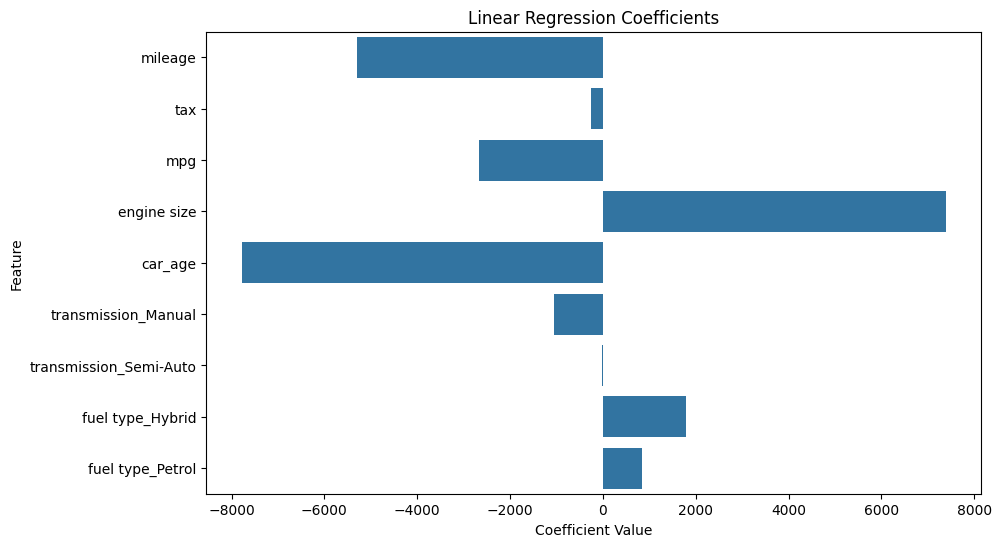

In [59]:
import seaborn as sns

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': carPredict.coef_
})

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df)
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

In [56]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': carPredict.coef_
})
print(coeff_df)

                  Feature  Coefficient
0                 mileage -5290.193615
1                     tax  -255.903835
2                     mpg -2663.393573
3             engine size  7391.031474
4                 car_age -7784.592734
5     transmission_Manual -1058.380684
6  transmission_Semi-Auto   -19.762476
7        fuel type_Hybrid  1783.654302
8        fuel type_Petrol   834.005356
